# One storm, every method, every sensor

The 9-10 January 2024 rainstorm, 16:00 to 11:00 UTC.

1. **Links to rain maps.** Five retrieval methods (from the two original implementations;
   `docs/METHODS.md`) turn each link's signal into path rain rates. Hourly totals are
   interpolated with IDW onto the MRMS 0.01° grid.
2. **Maps against radar.** Scored hour by hour against MRMS, on cells where both are valid.
3. **All sensors.** CML maps, a PWS map (same IDW) and MRMS compared pairwise; ASOS as the
   independent point check.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nyc_rain_maps import plots

from nyc_rain_maps.compare import compare_sensors
from nyc_rain_maps.pipeline import METHODS, run_event

START, END = ("2024-01-09 16:00", "2024-01-10 11:00")

In [2]:
for name in ["impl1_dynamic", "impl2_classical_dynamic", "impl2_classical_constant",
             "impl2_pycomlink", "impl2_nearby"]:
    print(f"{name:26s} {METHODS[name].description}")

impl1_dynamic              Dynamic baseline (200 min, qd 1 dB), gaps filled with q99 attenuation while PWS wet, ITU 2003
impl2_classical_dynamic    PyNNcml one-step dynamic baseline on min-RSL-filled series, ITU 2003
impl2_classical_constant   PyNNcml two-step: STD wet/dry (240, 1 dB) + constant baseline + 3 dB WAA, ITU 2003
impl2_pycomlink            pycomlink RSD wet/dry (240 min, q90 of 8-month record) + constant baseline + Leijnse WAA, ITU 2005
impl2_nearby               Nearby-link wet/dry + reference level (Overeem 2016) on 15-min min/max, ITU 2005


## Links to maps, scored against MRMS

`link_set="selected"` uses the links chosen in notebook 02. A 6-hour spin-up before the event
lets the baselines settle.

In [3]:
res = run_event(START, END, link_set="selected")
res.map_scores[["mean_ref", "mean_est", "rel_bias", "nrmse", "corr", "csi", "near_nrmse"]].round(2)

,mean_ref,mean_est,rel_bias,nrmse,corr,csi,near_nrmse
method,,,,,,,
impl1_dynamic,3.18,2.50,-0.21,0.74,0.68,0.88,0.69
impl2_classical_dynamic,3.18,2.52,-0.21,0.73,0.69,0.88,0.68
impl2_classical_constant,3.18,2.72,-0.14,0.46,0.89,0.85,0.37
impl2_pycomlink,3.18,2.75,-0.13,0.42,0.91,0.88,0.33
impl2_nearby,3.18,2.44,-0.23,0.48,0.90,0.85,0.40


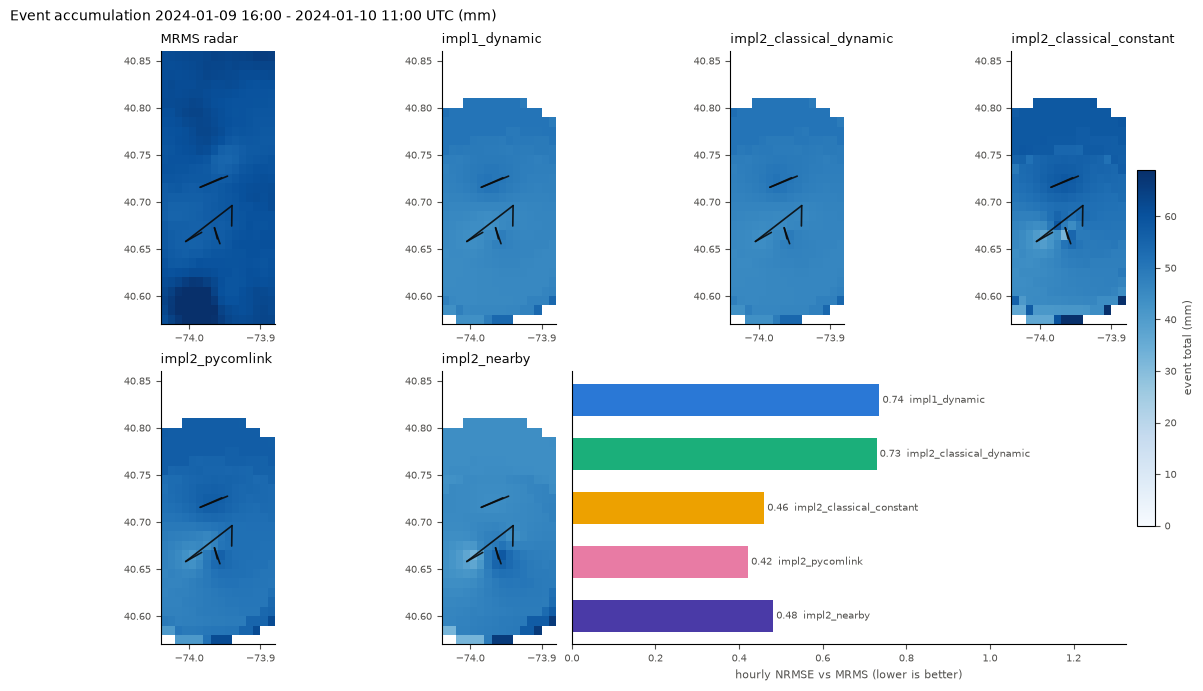

In [4]:
plots.event_comparison_figure(res);

`near_nrmse` restricts the score to cells within 2 km of a link, where the network actually
constrains the map. Per link, against the radar averaged along that link's path (no
interpolation involved):

In [5]:
res.link_scores[res.link_scores.method == "impl2_pycomlink"][["total_est", "total_radar", "rel_bias", "corr"]].round(2)

,total_est,total_radar,rel_bias,corr
link,,,,
3/sublink_3,57.16,57.43,-0.00,0.93
8/sublink_1,56.87,57.45,-0.01,0.93
12/sublink_2,40.83,55.90,-0.27,0.95
20/sublink_2,43.08,56.93,-0.24,0.95
31/sublink_1,47.24,56.91,-0.17,0.96
34/sublink_1,61.88,57.22,0.08,0.95
40/sublink_1,51.94,58.18,-0.11,0.96


## Every sensor on one grid

The PWS map uses the same IDW as the CML maps, after dropping stations whose event total is
outside the 5th-95th percentile (stuck or runaway gauges).

In [6]:
comp = compare_sensors(START, END, res=res)
print(comp.info)
comp.pairwise(near_km=2.0)[["estimate", "reference", "n", "rel_bias", "nrmse", "corr"]].round(2)

{'link_set': 'selected', 'n_links': 7, 'pws_stations': 28, 'pws_qc': 'event totals within p5-p95 (11.4-83.6 mm)', 'asos_stations': ['LGA', 'NYC']}


,estimate,reference,n,rel_bias,nrmse,corr
0,CML impl1_dynamic,MRMS,1577,-0.18,0.69,0.72
1,CML impl2_classical_dynamic,MRMS,1577,-0.18,0.68,0.73
2,CML impl2_classical_constant,MRMS,1577,-0.12,0.37,0.93
3,CML impl2_pycomlink,MRMS,1577,-0.11,0.33,0.94
4,CML impl2_nearby,MRMS,1577,-0.20,0.40,0.94
5,CML impl1_dynamic,PWS,1577,-0.12,0.77,0.68
6,CML impl2_classical_dynamic,PWS,1577,-0.11,0.76,0.69
7,CML impl2_classical_constant,PWS,1577,-0.05,0.44,0.91
8,CML impl2_pycomlink,PWS,1577,-0.04,0.41,0.92
9,CML impl2_nearby,PWS,1577,-0.14,0.45,0.91


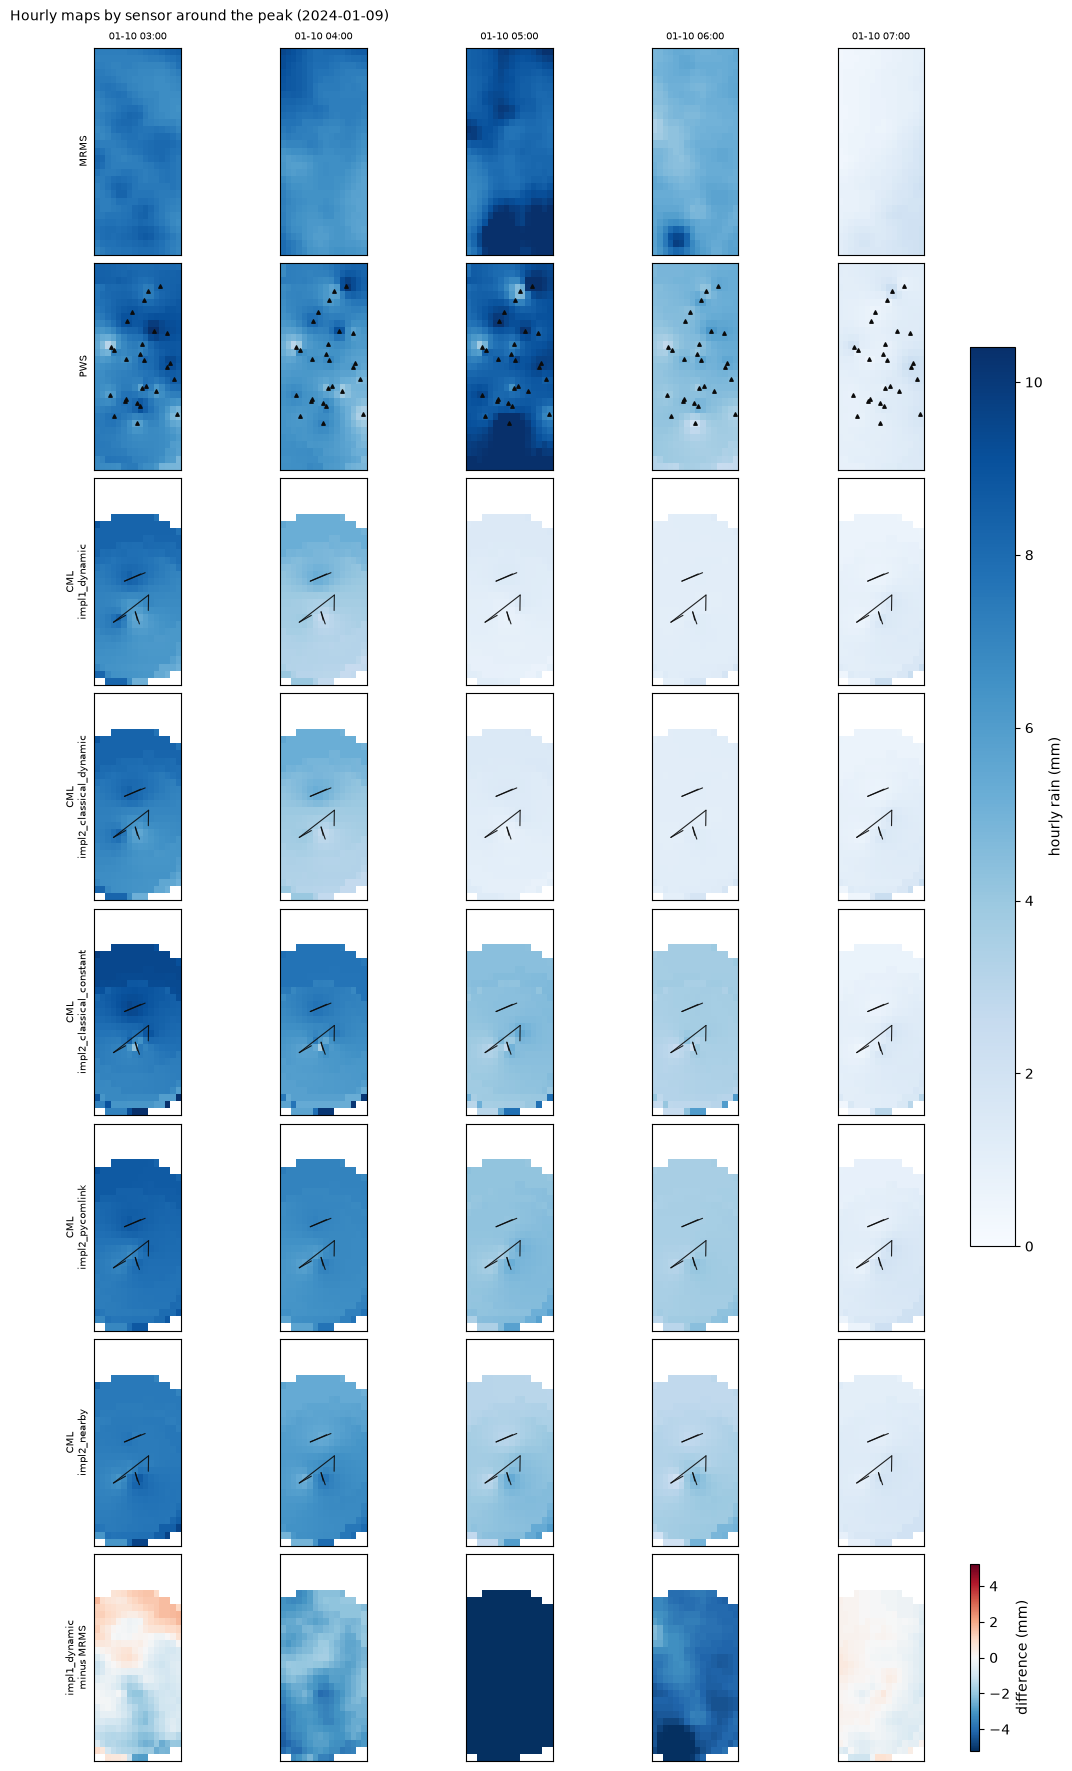

In [7]:
plots.sensor_snapshot_figure(comp, n_times=5);

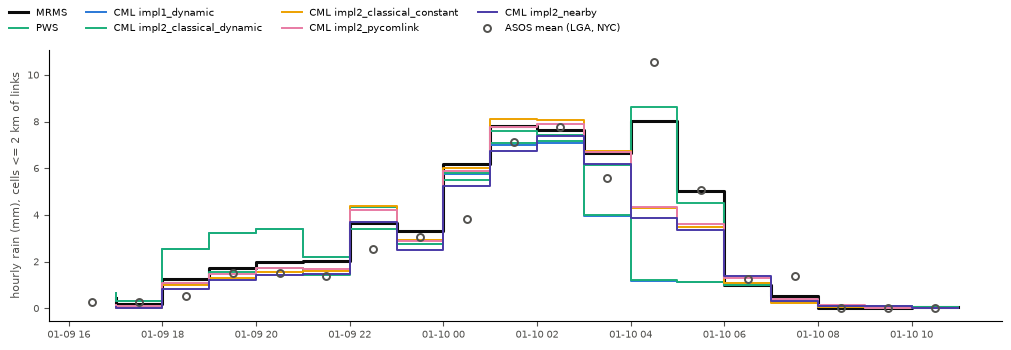

In [8]:
plots.sensor_series_figure(comp);

At the airport gauges, which no map used:

In [9]:
comp.points()[["map", "stations", "n", "rel_bias", "nrmse", "corr"]].round(2)

,map,stations,n,rel_bias,nrmse,corr
0,MRMS,"LGA,NYC",38,0.12,0.39,0.94
1,PWS,"LGA,NYC",38,0.19,0.40,0.95
2,CML impl1_dynamic,"LGA,NYC",38,-0.05,0.92,0.59
3,CML impl2_classical_dynamic,"LGA,NYC",38,-0.05,0.92,0.59
4,CML impl2_classical_constant,"LGA,NYC",38,0.08,0.74,0.78
5,CML impl2_pycomlink,"LGA,NYC",38,0.06,0.69,0.79
6,CML impl2_nearby,"LGA,NYC",38,-0.18,0.70,0.78


Next: `04_results.ipynb` - the same comparison over every event.